In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



---



### List รายชื่อ Class

0 jiankangshe (Healthy Tongue) ลิ้นสุขภาพดี<br>
1 botaishe (Tongue with peeling coating) ลิ้นลอก<br>
2 hongshe (Red tongue) ลิ้นสีแดง<br>
3 zishe (Purple tongue) ลิ้นสีม่วง<br>
4 pangdashe (Chubby tongue) ลิ้นอวบ<br>
5 shoushe (Thin tongue) ลิ้นบาง<br>
6 hongdianshe (Red dot tongue) ลิ้นจุดแดง<br>
7 liewenshe (Cracked tongue) ผิวแตก<br>
8 chihenshe (Dentate tongue) รอยแตกหยักขอบฟัน<br>
9 baitaishe (White coating tongue) ฝ้าสีขาว<br>
10 huangtaishe (Yellow coating tongue) ฝ้าสีเหลือง<br>
11 heitaishe (Black coating tongue) ฝ้าสีดำ<br>
12 huataishe (Smooth coating tongue) ผิวเรียบ<br>
13 shenquao (renal depression) โรค<br>
14 shenqutu (renal protrusion)  โรค<br>
15 gandanao (Hepatobiliary depression)  โรค<br>
16 gandantu (Hepatobiliary protrusion)  โรค<br>
17 piweiao (spleen and stomach depression)  โรค<br>
18 xinfeiao (heart and lung depression)  โรค<br>
19 xinfeitu (heart and lung protrusion)  โรค<br>

### ดูข้างใน **Dataset** ว่าแบ่ง Train, Val, Test มายังไง

ตัว Dataset นี้ ผมคิดว่าสัดส่วนน่าจะประมาณ **80:10:10** ครับ

#### Plot Train, Val, Test ออกมาดูจำนวนรูปภาพข้างในและ Bar Chart

Train: 5594 images
Val: 572 images
Test: 553 images


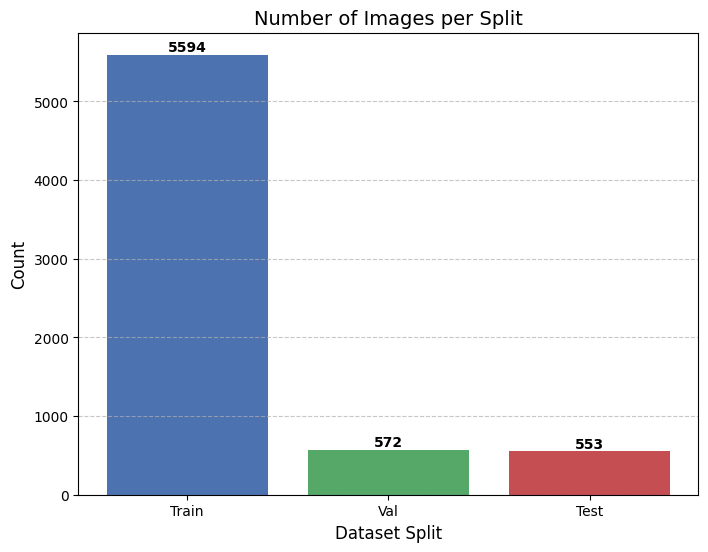

In [11]:
def count_and_plot_images(dataset_path):
    # กำหนดนามสกุลไฟล์ภาพที่ต้องการนับ
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

    splits = ['train', 'val', 'test']
    counts = []
    found_splits = []

    for split in splits:
        split_path = os.path.join(dataset_path, split)

        if os.path.exists(split_path):
            # นับไฟล์ทั้งหมด
            count = sum([len([f for f in files if f.lower().endswith(valid_extensions)])
                         for r, d, files in os.walk(split_path)])

            counts.append(count)
            found_splits.append(split.capitalize())
            print(f"{split.capitalize()}: {count} images")
        else:
            print(f"ไม่พบโฟลเดอร์: {split}")

    # --- ส่วนการ Plot กราฟ ---
    if counts:
        plt.figure(figsize=(8, 6))
        # สร้าง Bar Chart
        bars = plt.bar(found_splits, counts, color=['#4C72B0', '#55A868', '#C44E52'])

        # เพิ่มตัวเลขด้านบนแท่งกราฟ
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
                     int(yval), ha='center', va='bottom', fontweight='bold')

        plt.title('Number of Images per Split', fontsize=14)
        plt.xlabel('Dataset Split', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.show()
    else:
        print("ไม่มีข้อมูลสำหรับพล็อตพล็อตครับ")

# ใส่ที่อยู่โฟลเดอร์ Dataset ของคุณที่นี่
dataset_path = 'drive/MyDrive/shezhenv3-txt'
count_and_plot_images(dataset_path)

### ดูข้างใน **Train Dataset** ว่าจำนวน Class ในแต่ละ Label มีเท่าไหร่ (ใน 1 Label จะมีหลายๆ ตัวเลข เช่น  0 + 5 + 9)

ในไฟล์ Label 1 ไฟล์ จะมี Class มากกว่า 1 ตัว<br>
ซึ่งในโลกจริง ลิ้นของคนจะมีอยู่หลายลักษณะใน 1 ลิ้น เลยจะมี Class มากกว่า 1 ตัว<br>
ผมจึง Plot Class ทั้งหมดออกมาดูให้เห็นภาพรวม ว่า Label แต่ละตัว ตัวไหนมี Class ซ้ำกันเยอะสุด

#### ดูจำนวนเฉพาะใน **Train Folder**



In [13]:
# 1. ระบุพาธ
label_path = '/content/drive/MyDrive/shezhenv3-txt/train/labels/'

# สร้าง Dictionary สำหรับแปลงเลขเป็นชื่อ
class_map = {
    '0': 'Healthy Tongue',
    '1': 'Tongue with peeling coating',
    '2': 'Red tongue',
    '3': 'Purple tongue',
    '4': 'Chubby tongue',
    '5': 'Thin tongue',
    '6': 'Red dot tongue',
    '7': 'Cracked tongue',
    '8': 'Dentate tongue',
    '9': 'White coating tongue',
    '10': 'Yellow coating tongue',
    '11': 'Black coating tongue',
    '12': 'Smooth coating tongue'
}

combination_list = []

# 2. อ่านไฟล์และรวมกลุ่มคลาส
if os.path.exists(label_path):
    for label_file in os.listdir(label_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_path, label_file), 'r') as f:
                # ดึง class id ออกมา
                classes = [line.split()[0] for line in f.readlines() if line.strip()]

                if classes:
                    # ทำการดึงเลขที่ไม่ซ้ำและเรียงลำดับ
                    unique_ids = sorted(list(set(classes)), key=int)

                    # --- ส่วนที่เพิ่ม: แปลงเลขเป็นชื่อ ---
                    # ถ้าเจอเลขที่ไม่มีใน dict จะแสดงเป็น "Unknown (เลขนั้น)"
                    unique_names = [class_map.get(c, f"Unknown({c})") for c in unique_ids]

                    # รวมเป็นชื่อ combination
                    combo_str = " + ".join(unique_names)
                    combination_list.append(combo_str)

    # 3. คำนวณสถิติ
    df_combos = pd.DataFrame(combination_list, columns=['Combo'])
    combo_counts = df_combos['Combo'].value_counts()

    # --- ปรับการแสดงผลของ Pandas ---
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None) # เพิ่มตรงนี้เพื่อให้ชื่อยาวๆ ไม่ถูกตัด

    print(f"--- ตรวจพบชุดผสมทั้งหมด {len(combo_counts)} รูปแบบ ---")
    print(combo_counts)

    # คืนค่าเดิมให้ Pandas
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_colwidth')
else:
    print("ไม่พบโฟลเดอร์ครับ")

--- ตรวจพบชุดผสมทั้งหมด 510 รูปแบบ ---
Combo
White coating tongue                                                                                                 776
Cracked tongue + White coating tongue                                                                                369
Red dot tongue + White coating tongue                                                                                318
Dentate tongue + White coating tongue                                                                                294
Red tongue + White coating tongue                                                                                    217
Yellow coating tongue                                                                                                181
Chubby tongue + White coating tongue                                                                                 153
Red tongue + Red dot tongue + White coating tongue                                                          

#### Plot เฉพาะ **Train Folder** ออกมาเป็น Bar Chart ดู 10 อันดับแรก

/tmp/ipykernel_11568/460237759.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


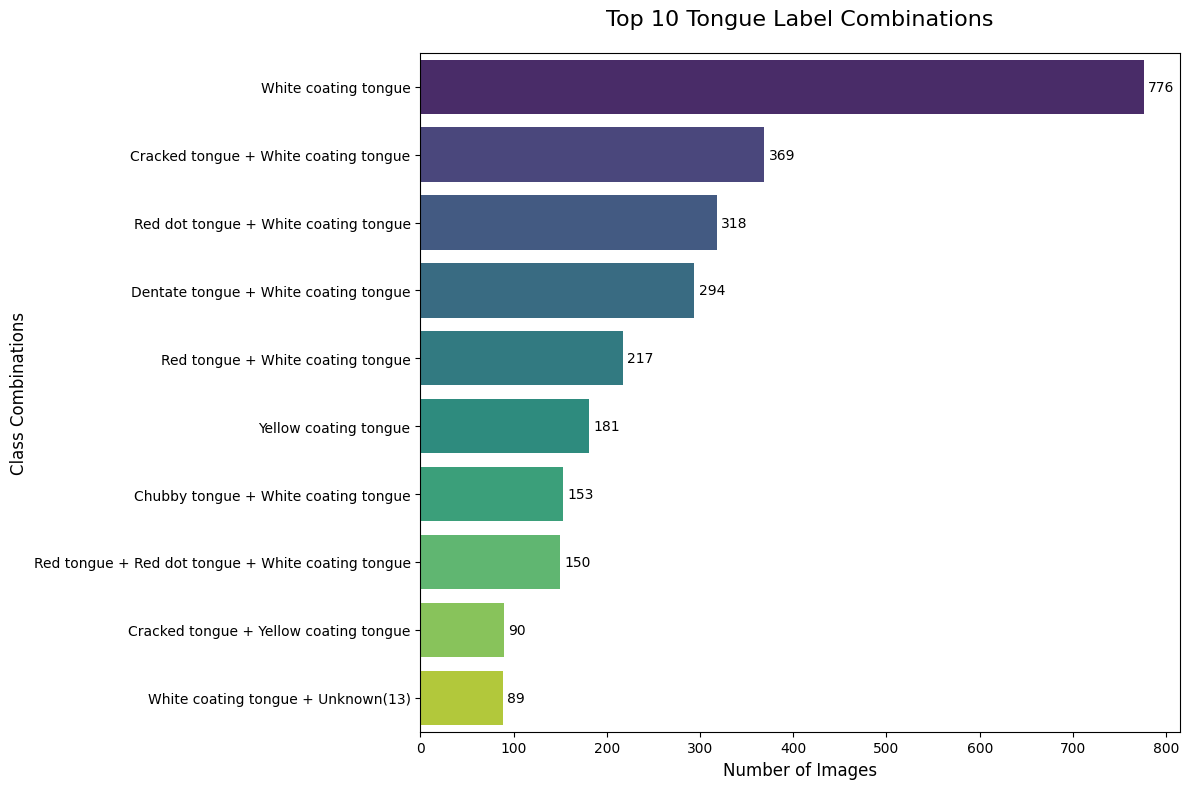

In [9]:
if not combo_counts.empty:
    # 4. เตรียมข้อมูล Top 10
    top_10_combos = combo_counts.head(10).reset_index()
    top_10_combos.columns = ['Combination', 'Count']

    # 5. เริ่มต้นสร้างกราฟ
    plt.figure(figsize=(12, 8))

    # ใช้ Barplot จาก Seaborn
    ax = sns.barplot(
        x='Count',
        y='Combination',
        data=top_10_combos,
        palette='viridis' # ไล่เฉดสีให้ดูโมเดิร์น
    )

    # เพิ่มตัวเลขจำนวนที่ปลายแท่งกราฟ
    for i in ax.containers:
        ax.bar_label(i, padding=3)

    # ตั้งชื่อกราฟและแกน
    plt.title('Top 10 Tongue Label Combinations', fontsize=16, pad=20)
    plt.xlabel('Number of Images', fontsize=12)
    plt.ylabel('Class Combinations', fontsize=12)

    # ปรับ Layout ไม่ให้ตัวหนังสือล้นขอบ
    plt.tight_layout()

    # แสดงผล
    plt.show()
else:
    print("ไม่มีข้อมูลสำหรับพล็อตครับ")

#### ดูจำนวนทั้งหมดใน **Train, Valid, Test**

In [3]:
import os
import pandas as pd

# 1. ระบุพาธหลัก
base_path = '/content/drive/MyDrive/shezhenv3-txt/'
splits = ['train', 'val', 'test']

# Dictionary แปลงเลขเป็นชื่อ
class_map = {
    '0': 'Healthy Tongue',
    '1': 'Tongue with peeling coating',
    '2': 'Red tongue',
    '3': 'Purple tongue',
    '4': 'Chubby tongue',
    '5': 'Thin tongue',
    '6': 'Red dot tongue',
    '7': 'Cracked tongue',
    '8': 'Dentate tongue',
    '9': 'White coating tongue',
    '10': 'Yellow coating tongue',
    '11': 'Black coating tongue',
    '12': 'Smooth coating tongue'
}

all_combinations = []

# 2. อ่านไฟล์จากทุก Split (train, val, test)
for split in splits:
    label_path = os.path.join(base_path, split, 'labels')

    if os.path.exists(label_path):
        for label_file in os.listdir(label_path):
            if label_file.endswith('.txt'):
                with open(os.path.join(label_path, label_file), 'r') as f:
                    classes = [line.split()[0] for line in f.readlines() if line.strip()]

                    if classes:
                        unique_ids = sorted(list(set(classes)), key=int)
                        unique_names = [class_map.get(c, f"Unknown({c})") for c in unique_ids]
                        combo_str = " + ".join(unique_names)
                        all_combinations.append(combo_str)
    else:
        print(f"ไม่พบโฟลเดอร์: {split}")

# 3. คำนวณสถิติและแสดงผลเฉพาะจำนวน
if all_combinations:
    df_combos = pd.DataFrame(all_combinations, columns=['Combo'])
    combo_counts = df_combos['Combo'].value_counts()

    print(f"--- ตรวจพบชุดผสมทั้งหมด (รวมทุก Split) {len(combo_counts)} รูปแบบ ---")
    print("-" * 50)

    # ตั้งค่าให้แสดงผลครบถ้วน
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', None)

    print(combo_counts)

    # คืนค่าเดิมให้ Pandas
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_colwidth')
else:
    print("ไม่พบข้อมูลสถิติครับ")

--- ตรวจพบชุดผสมทั้งหมด (รวมทุก Split) 555 รูปแบบ ---
--------------------------------------------------
Combo
White coating tongue                                                                                                 951
Cracked tongue + White coating tongue                                                                                490
Red dot tongue + White coating tongue                                                                                365
Dentate tongue + White coating tongue                                                                                341
Red tongue + White coating tongue                                                                                    263
Yellow coating tongue                                                                                                231
Red tongue + Red dot tongue + White coating tongue                                                                   179
Chubby tongue + White coating tongue      

#### Plot ทั้งหมด ออกมาเป็น Bar Chart ดู 10 อันดับแรก

/tmp/ipykernel_1440/613901203.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


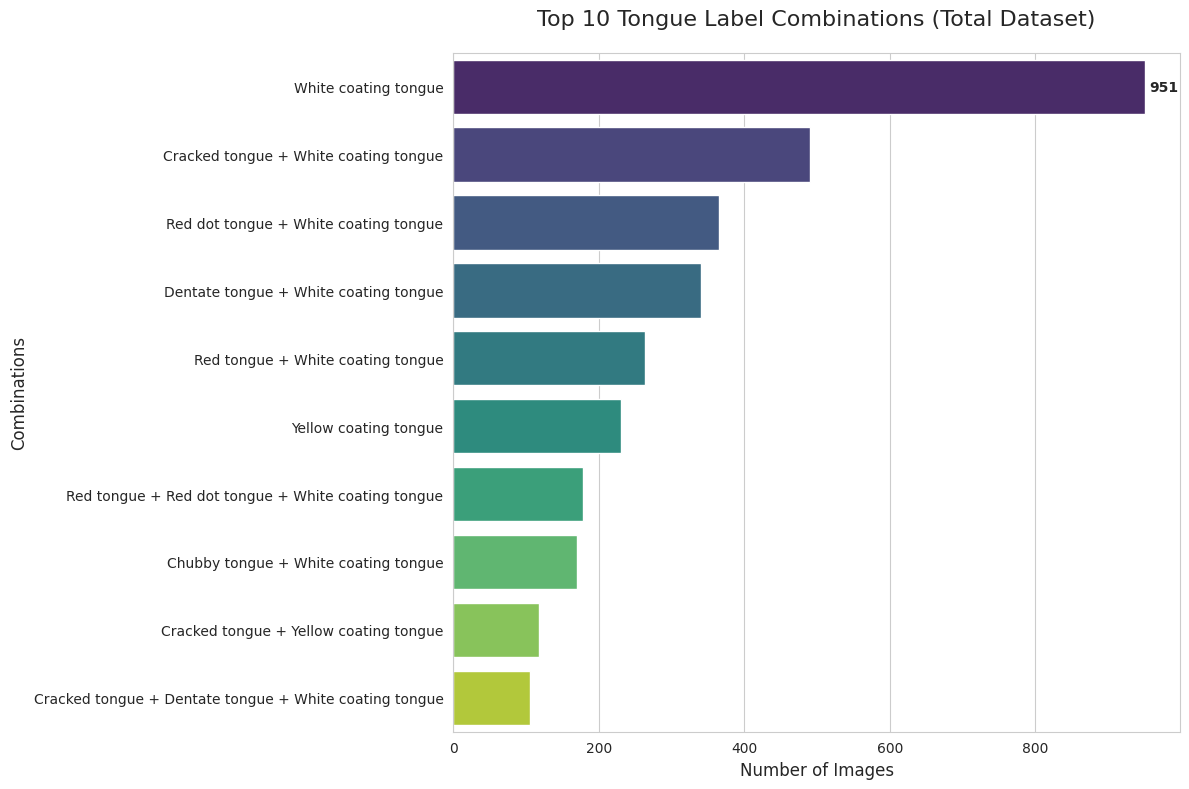

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ตั้งค่าพาธและอ่านข้อมูล
base_path = '/content/drive/MyDrive/shezhenv3-txt/'
splits = ['train', 'val', 'test']
class_map = {
    '0': 'Healthy Tongue', '1': 'Tongue with peeling coating', '2': 'Red tongue',
    '3': 'Purple tongue', '4': 'Chubby tongue', '5': 'Thin tongue',
    '6': 'Red dot tongue', '7': 'Cracked tongue', '8': 'Dentate tongue',
    '9': 'White coating tongue', '10': 'Yellow coating tongue',
    '11': 'Black coating tongue', '12': 'Smooth coating tongue'
}

all_combinations = []

# อ่านไฟล์จากทุกโฟลเดอร์
for split in splits:
    label_path = os.path.join(base_path, split, 'labels')
    if os.path.exists(label_path):
        for label_file in os.listdir(label_path):
            if label_file.endswith('.txt'):
                with open(os.path.join(label_path, label_file), 'r') as f:
                    classes = [line.split()[0] for line in f.readlines() if line.strip()]
                    if classes:
                        unique_ids = sorted(list(set(classes)), key=int)
                        unique_names = [class_map.get(c, f"Unknown({c})") for c in unique_ids]
                        all_combinations.append(" + ".join(unique_names))

# 2. เตรียมข้อมูลและ Plot กราฟ
if all_combinations:
    # นับจำนวนและเลือกมาเฉพาะ Top 10
    combo_counts = pd.Series(all_combinations).value_counts().head(10)

    # สร้างกราฟ
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid") # เพิ่มเส้นตารางจางๆ ให้ดูง่าย

    ax = sns.barplot(
        x=combo_counts.values,
        y=combo_counts.index,
        palette='viridis'
    )

    # ใส่ตัวเลขกำกับท้ายแท่ง
    ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight='bold')

    plt.title('Top 10 Tongue Label Combinations (Total Dataset)', fontsize=16, pad=20)
    plt.xlabel('Number of Images', fontsize=12)
    plt.ylabel('Combinations', fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("ไม่พบข้อมูลสำหรับทำกราฟครับ")

### ดูข้างใน **Train Dataset** ว่าจำนวน Class ในแต่ละ Label แยกออกมานับเป็นตัวเดี่ยวจริงๆ ได้เท่าไหร่ (เฉพาะแค่ตัวเลขตัวเดียว)

#### ดูจำนวนทั้งหมดใน **Train, Valid, Test**

In [3]:
def count_instances(label_path):
    if not os.path.exists(label_path):
        return {}

    counts = {}
    for filename in os.listdir(label_path):
        if filename.endswith('.txt'):
            with open(os.path.join(label_path, filename), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        cls = int(parts[0])
                        counts[cls] = counts.get(cls, 0) + 1
    return counts

# --- 1. กำหนด Path หลัก ---
base_path = '/content/drive/MyDrive/shezhenv3-txt/'
sets = ['train', 'val', 'test']

# --- 2. ดึงข้อมูลจำนวน Instance ---
all_data = {}
for s in sets:
    all_data[s] = count_instances(os.path.join(base_path, s, 'labels'))

# --- 3. แปลงเป็น DataFrame และจัดการลำดับ ---
df = pd.DataFrame(all_data).fillna(0).astype(int)

# --- เพิ่มบรรทัดนี้เพื่อเรียงเลข Class ID จากน้อยไปมาก ---
df = df.sort_index()

df.index.name = 'Class ID'

# คำนวณผลรวมรายบรรทัด (Total per Class)
df['Total'] = df.sum(axis=1)

# คำนวณผลรวมรายคอลัมน์ (Total per Set)
total_row = df.sum().to_frame().T
total_row.index = ['Total Sum']

# รวมตารางข้อมูลกับแถวสรุปผลรวมเข้าด้วยกัน
df_final = pd.concat([df, total_row])

# --- 4. แสดงผลข้อมูล ---
print("\n--- ตารางสรุปจำนวน Instance (เรียงตาม Class ID) ---")
pd.set_option('display.max_rows', None)  # ให้แสดงทุกบรรทัด
print(df_final)
pd.reset_option('display.max_rows')


--- ตารางสรุปจำนวน Instance (เรียงตาม Class ID) ---
           train   val  test  Total
0             11    11     1     23
1            553    65     2    620
2           1279   118   148   1545
3            209    25    18    252
4            622    47    34    703
5            224    35    30    289
6           2578   633   514   3725
7           1493   174   282   1949
8           1316   166    60   1542
9           4379   391   397   5167
10           977    81    98   1156
11           107    15     3    125
12           267    12    12    291
13           436    40    31    507
14             1     1     0      2
15           269    11    12    292
16             1     8     0      9
17           171     9     7    187
18             1     1     0      2
19           325    36    16    377
Total Sum  15219  1879  1665  18763


#### Plot ทั้งหมดออกมาเป็น Bar Chart

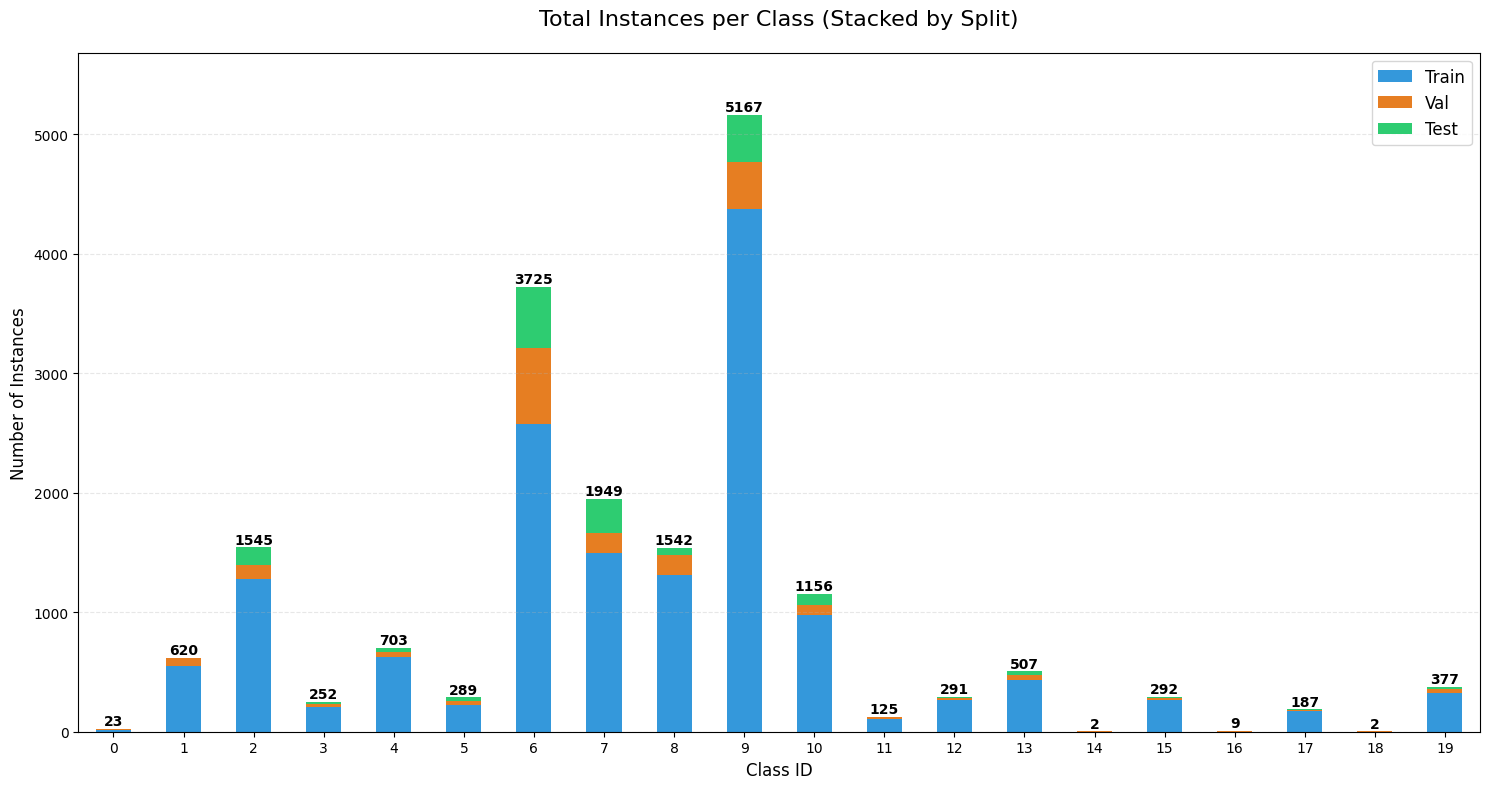

In [4]:
def count_instances(label_path):
    if not os.path.exists(label_path):
        return {}
    counts = {}
    for filename in os.listdir(label_path):
        if filename.endswith('.txt'):
            with open(os.path.join(label_path, filename), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        cls = int(parts[0])
                        counts[cls] = counts.get(cls, 0) + 1
    return counts

# 1. เตรียมข้อมูล
base_path = '/content/drive/MyDrive/shezhenv3-txt/'
sets = ['train', 'val', 'test']
all_data = {s: count_instances(os.path.join(base_path, s, 'labels')) for s in sets}

# 2. จัดการ DataFrame ให้เรียงลำดับ Class ID
df = pd.DataFrame(all_data).fillna(0).astype(int)
df = df.sort_index()  # เรียง Class ID 0, 1, 2...
df.index.name = 'Class ID'

# 3. พล็อตกราฟ
plt.figure(figsize=(15, 8))
# ใช้สีที่แยกแยะง่าย: Blue (Train), Orange (Val), Green (Test)
ax = df.plot(kind='bar', stacked=True, figsize=(15, 8), color=['#3498db', '#e67e22', '#2ecc71'], ax=plt.gca())

# --- เพิ่มตัวเลขรวมที่ด้านบนสุดของแต่ละแท่ง ---
totals = df.sum(axis=1)
for i, total in enumerate(totals):
    ax.text(i, total + 5, int(total), ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. ตกแต่งรายละเอียด
plt.title('Total Instances per Class (Stacked by Split)', fontsize=16, pad=20)
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.legend(['Train', 'Val', 'Test'], fontsize=12)
plt.xticks(rotation=0) # ให้เลข Class ID วางแนวตั้งปกติ
plt.grid(axis='y', linestyle='--', alpha=0.3)

# เผื่อพื้นที่ด้านบนให้ตัวเลขไม่ติดขอบ
plt.ylim(0, max(totals) * 1.1)

plt.tight_layout()
plt.show()

### สรุปได้ว่า
- Dataset ขาดรูป Healthy เป็นอย่างมาก เพราะใน train มีแค่ 11